# CSC3831 Coursework Part 1: Data Engineering



## Table Of Contents:
### 0. Imports and Loading Data [0]
-  #### 0.1 Added Imports
-  #### 0.2 Global Variables
### 1. Data Understanding [7]
-  #### 1.1 Dataset overview  
-  #### 1.2 Summary statistics  
-  #### 1.3 Missing values  
-  #### 1.4 Outliers records   
-  #### 1.5 EDA summary  
### 2. Outlier Identification [10]
-  #### 2.1 Statistical outlier detection
-  #### 2.2 Algorithmic outlier detection
-  #### 2.3 Comparison of statistical vs algorithmic results
-  #### 2.4 Benefits and Detriments
### 3. Imputation [10]
-  #### 3.1 Identify features to impute or remove
-  #### 3.2 KNN Imputation
-  #### 3.3 MICE Imputation
-  #### 3.4 Compare feature distributions
-  #### 3.5 Regressor comparison on three datasets

# 0. Imports and Loading Data

In [1249]:
# Loading in standard packages for analysis, feel free to add an extra packages you'd like to use here
import random
import pandas as pd
import numpy as np
import seaborn as sns
import missingno as msno
import matplotlib.pyplot as plt

# Loading in the corrupted dataset to be used in analysis and imputation
hc_path = 'https://raw.githubusercontent.com/PaoloMissier/CSC3831-2021-22/main/IMPUTATION/TARGET-DATASETS/CORRUPTED/HOUSES/houses_0.1_MAR.csv'
houses_corrupted = pd.read_csv(hc_path, header=0)
# Remove an artifact from the dataset
houses_corrupted.drop(["Unnamed: 0"], axis=1, inplace=True)

Above we've loaded in a corrupted version of a housing dataset. The anomalies need to be dealt with and missing values imputed.

## 0.1 Added Imports

In [1250]:
from sklearn.ensemble import IsolationForest

## 0.2 Global Variables

In [1251]:
all_columns = ['median_house_value', 'median_income', 'housing_median_age',
            'total_rooms', 'total_bedrooms', 'population', 'households',
            'longitude', 'latitude']
null_columns = ['median_income', 'housing_median_age', 'population']

# 1. Data Understanding [7]
### Tasks:
- Perform ad hoc EDA to understand and describe what you see in the raw dataset
  - Include graphs, statistics, and written descriptions as appropriate
  - Any extra information about the data you can provide here is useful, think about performing an analysis (ED**A**), what would you find interesting or useful?
- Identify features with missing records, outlier records


## 1.1 Dataset overview

In [1252]:
houses_corrupted.head(10)

,median_house_value,median_income,housing_median_age,total_rooms,total_bedrooms,population,households,latitude,longitude
0,452600.0,8.3252,41.0,880.0,129.0,322.0,126.0,37.88,-122.23
1,358500.0,8.3014,21.0,7099.0,1106.0,2401.0,1138.0,37.86,-122.22
2,352100.0,7.2574,52.0,1467.0,190.0,NaN,177.0,37.85,-122.24
3,341300.0,5.6431,52.0,1274.0,235.0,NaN,219.0,37.85,-122.25
4,342200.0,3.8462,52.0,1627.0,280.0,565.0,259.0,37.85,-122.25
5,269700.0,4.0368,52.0,919.0,213.0,413.0,193.0,37.85,-122.25
6,299200.0,3.6591,52.0,2535.0,489.0,1094.0,514.0,37.84,-122.25
7,241400.0,3.1200,52.0,3104.0,687.0,1157.0,647.0,37.84,-122.25
8,226700.0,2.0804,42.0,2555.0,665.0,1206.0,595.0,37.84,-122.26
9,261100.0,3.6912,52.0,3549.0,707.0,1551.0,714.0,37.84,-122.25


In [1253]:
houses_corrupted.shape

(20640, 9)

In [1254]:
houses_corrupted.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   median_house_value  20640 non-null  float64
 1   median_income       18576 non-null  float64
 2   housing_median_age  18576 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20640 non-null  float64
 5   population          18576 non-null  float64
 6   households          20640 non-null  float64
 7   latitude            20640 non-null  float64
 8   longitude           20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


Based on the column names, the dataset appears to describe both housing and economic characteristics for different geographic locations. After inputting the first 10 locations into google maps, it appears all of them track to neighborhoods in California, USA. Therefore, each row likely corresponds to small neighborhoods, but i'm uncertain whether this whole dataset contributes to just California, or a wider region. Fortunately, the key point to focus on is that each record describes different housing locations, linking to their economic attributes.

Looking at 'houses_corrupted.shape' there are 20,640 rows in total and 9 columns all together, where each row corresponds to a geographic location.

Looking at 'houses_corrupted.info()', 3 rows contain missing values which are median_income, housing_median_age, and population. Missing values will be analysed properly later on through the coursework.

Now let's move on to the columns of the dataset. The median_house_value is very likely to be the target variable, assuming it means the average house prince in that area. median_income is the average income per location. housing_median_age is the average housing age per location. total_rooms and total_bedrooms are the number of rooms/bedrooms in total per location. The population column is the total number of people per location. Finally, the households column is the total number of houses per location.


## 1.2 Summary statistics 

In [1255]:
houses_corrupted.describe()

,median_house_value,median_income,housing_median_age,total_rooms,total_bedrooms,population,households,latitude,longitude
count,20640.000000,18576.000000,18576.000000,20640.000000,20640.000000,18576.000000,20640.000000,20640.000000,20640.000000
mean,206855.816909,3.929958,28.324182,2635.763081,537.898014,1488.069283,499.539680,35.631861,-119.569704
std,115395.615874,1.964296,12.584914,2181.615252,421.247906,1170.585810,382.329753,2.135952,2.003532
min,14999.000000,0.499900,1.000000,2.000000,1.000000,3.000000,1.000000,32.540000,-124.350000
25%,119600.000000,2.560300,18.000000,1447.750000,295.000000,839.000000,280.000000,33.930000,-121.800000
50%,179700.000000,3.572400,28.000000,2127.000000,435.000000,1227.000000,409.000000,34.260000,-118.490000
75%,264725.000000,4.870050,37.000000,3148.000000,647.000000,1803.000000,605.000000,37.710000,-118.010000
max,500001.000000,15.000100,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,41.950000,-114.310000


In [1256]:
houses_corrupted.skew()

median_house_value    0.977763
median_income         1.587611
housing_median_age    0.085426
total_rooms           4.147343
total_bedrooms        3.453073
population            4.825861
households            3.410438
latitude              0.465953
longitude            -0.297801
dtype: float64

### Analysis per column from written statistics displayed:

median_house_value:
-  House prices between 14.999k and just over 500k, suggesting wide spread of house prices.
-  Right skewed as shown positive.

median_income:
-  Most neighborhoods contain people with lower income as the median is much more closer to min than max.
-  Right skewed as shown positive.

housing_median_age:
-  The ages are between 1 and 52. However, looking at the interquartile range of 18 and 37, it suggests most locations consist of housings that are neither old or new. 
-  Right skewed but extremely close to 0. Therefore, almost symmetrical around the median.

total_rooms:
-  Number of rooms per neighborhood are between 2 and 39,320. Therefore, this dataset likely includes both extremely small and large neighborhoods.
- Strongly right skewed which means a small number of neighborhoods have extremely many rooms.

total_bedrooms:
-  Data shows very similar to total_rooms which suggests a high correlation

population:
-  Also very similar to total_rooms as it ranges from 3 to 35,682 per area, suggesting the dataset contains neighborhoods being either extremely low and highly populated.
-  Strongly right skewed

households:
-  Number of houses per neighborhood range between 1 and 6,082.
-  Strongly right skewed.

After analysing just from the describe and skew tables, I can strongly say that total_rooms, total_bedrooms, population, and households all have a strong correlation between each other. This means one column has a big affect on the other three. Also, only these four columns have very strong skews.
However, it would be best to visually prove this analysis by using a heatmap:

<Axes: >

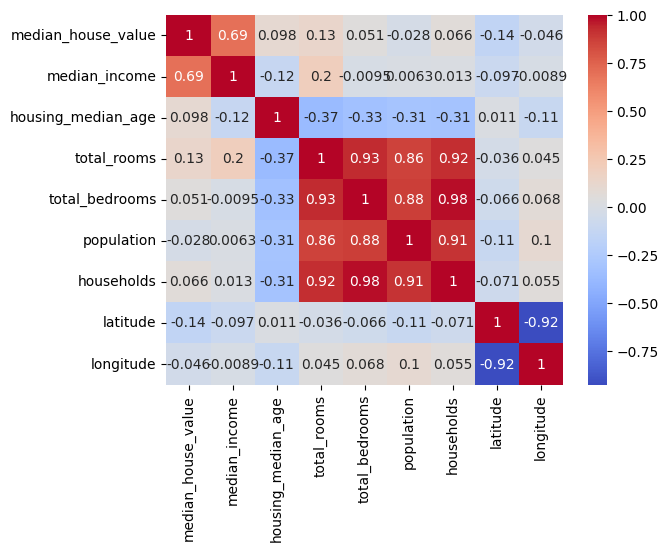

In [1257]:
sns.heatmap(houses_corrupted.corr(), annot=True, cmap='coolwarm')

You can see that big red box near the centre consists of these four columns. However, I was unable to analyse that median_income and median_house_value have a strong correlation. This suggests that most neighborhoods consists of people that have higher incomes, are very likely to have higher priced houses.

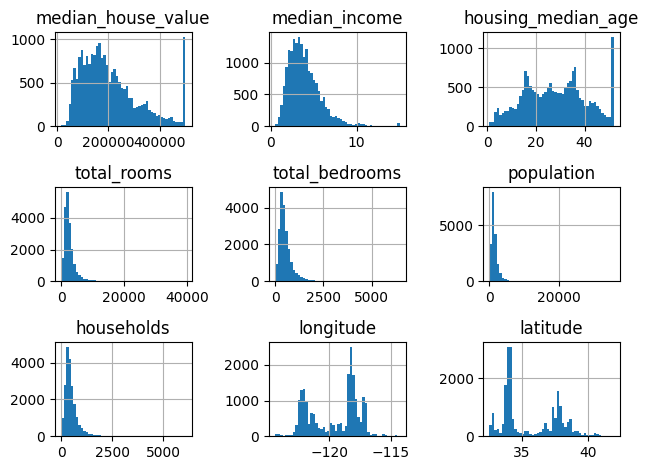

In [1258]:
houses_corrupted[all_columns].hist(
        bins=50)
plt.tight_layout()

In these histograms, total_rooms, total_bedrooms, population, and households are extremely right skewed, which shows most areas have the average number of these characteristics. 

median_house_value has a long right tail which shows some neighborhoods have much higher house prices than the rest. The same with housing_median_age where majority of neighborhoods have younger or middle-aged housing, but an extremely small minority of neighborhoods contain very old houses.

Looking at median_income, it has a right skewed distribution, suggesting most neighborhoods are in a relatively narrow income band whilst there are a small number of high‑income areas.

## 1.3 Missing values 

This section only focuses on identifying the missing values. They will be handled later on through this coursework.

In [1259]:
houses_corrupted.isnull().sum()

median_house_value       0
median_income         2064
housing_median_age    2064
total_rooms              0
total_bedrooms           0
population            2064
households               0
latitude                 0
longitude                0
dtype: int64

Looking at the series above, it seems that only three of the columns contain missing values. What's interesting is that these columns have exactly 2064 missing entries which suggests that when a value is missing, all three variables tend to be missing together in the same row. Let's see if this is the case.

In [1260]:
any_missing_rows = houses_corrupted[houses_corrupted.isnull().any(axis=1)]
print(any_missing_rows[null_columns].head(10))
print(any_missing_rows.shape)

    median_income  housing_median_age  population
2          7.2574                52.0         NaN
3          5.6431                52.0         NaN
10         3.2031                 NaN       910.0
14            NaN                52.0      1212.0
16            NaN                52.0       793.0
17            NaN                52.0         NaN
18            NaN                 NaN       990.0
19            NaN                52.0       690.0
20            NaN                40.0       409.0
21            NaN                 NaN       929.0
(5581, 9)


As you can see, these first 10 rows contain one or two null values, and the total number of rows containing at least one is 5581 (more than 2064). Furthermore, not one row is shown to have 3 consecutive null values. However, this does not mean the same is applied to the rest of the dataset. 

In [1261]:
three_missing_rows = houses_corrupted[houses_corrupted[null_columns].isnull().all(axis=1)]
print(three_missing_rows[null_columns])
print(f'Shape: {three_missing_rows.shape}')

       median_income  housing_median_age  population
802              NaN                 NaN         NaN
813              NaN                 NaN         NaN
1278             NaN                 NaN         NaN
4158             NaN                 NaN         NaN
4635             NaN                 NaN         NaN
4752             NaN                 NaN         NaN
6121             NaN                 NaN         NaN
6127             NaN                 NaN         NaN
6263             NaN                 NaN         NaN
6267             NaN                 NaN         NaN
6273             NaN                 NaN         NaN
6280             NaN                 NaN         NaN
6940             NaN                 NaN         NaN
6951             NaN                 NaN         NaN
7021             NaN                 NaN         NaN
7030             NaN                 NaN         NaN
7455             NaN                 NaN         NaN
7661             NaN                 NaN      

Throughout the whole dataset, there are 37 rows in total that have 3 null values in the columns: median_income, housing_median_age, and population. 

As I mentioned before, I will handle these missing values later on through the coursework. Some rows will be handled differently depending on the number of missing values per row.

## 1.4 Outliers records 

In [1262]:
Q1 = houses_corrupted[all_columns].quantile(0.25)
Q3 = houses_corrupted[all_columns].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = (houses_corrupted[all_columns] < lower_bound) | (houses_corrupted[all_columns] > upper_bound)
print(outliers.sum())

median_house_value    1071
median_income          562
housing_median_age       0
total_rooms           1287
total_bedrooms        1282
population            1077
households            1220
longitude                0
latitude                 0
dtype: int64


Above shows the total number of outliers there are per column in the whole dataset using the IQR method.

There are over 1000 outliers for columns: median_house_value, total_rooms, total_bedrooms, population, and households. Since these are related to housing and neighborhood sizing, it suggests these outliers come from neighborhoods that are extremely large, and are being compared to average sized areas.

With median_income and housing_median_age having a number of outliers between a few and none, suggests that income levels and housing ages vary a lot less that the rest of the housing attributes.

Both longitude and latitude are expected to have 0 outliers when my suspicions were that the locations of these housing areas are either in California or close by, based from inputting the values in Google Maps.

Initially, I had worries about finding outliers. Since this dataset contains null values, I was very curious to know how I could ensure the IQR method skips past the null values. It turns out in pandas, the quantile() function automatically ignores NaNs when computing Q1 and Q3, and the comparisons used to flag outliers (second-last line) return False for missing values. This means that the null values are excluded from the calculations, and are never directly marked as outliers.

## 1.5 EDA Summary

Overall, the dataset appears to describe housing and economic characteristics of different neighborhoods, with median_house_value as the likely target and other variables capturing income, housing characteristics, population, and location. The distributions show that price and size‑related variables are strongly right‑skewed with some very large values, while income and housing age are less extreme. Missing‑value analysis indicates that only median_income, housing_median_age, and population contain gaps, and these tend to be missing together in about 10% of rows. The IQR method confirms that outliers are concentrated in the price and size variables, suggesting a small number of unusually large or expensive neighborhoods that will need handled later.

# 2. Outlier Identification [10]
### Tasks:
- Utilise a statistical outlier detection approach (i.e., **no** KNN, LOF, 1Class SVM)
- Utilise an algorithmic outlier detection method of your choice
- Compare results and decide what to do with identified outliers
  - Include graphs, statistics, and written descriptions as appropriate
- Explain what you are doing, and why your analysis is appropriate
- Comment on benefits/detriments of statistical and algorithmic outlier detection approaches

## 2.1 Statistical Outlier Detection

In this section, I will use the IQR method (Interquartile Range) to detect the outliers. IQR is calculated by finding the median of the lower half of the data (Q1) and the median of the upper half of the data (Q3). Then IQR is equal to Q3 minus Q1. Once the IQR value is obtained, outliers can be found by treating any value below 
Q1 − 1.5 × IQR or above Q3 + 1.5 × IQR as extreme. Points inside this interval are considered typical for that feature, while points outside it are flagged as statistical outliers. This rule is widely used because it is simple, robust to moderate skewness, and does not require the data to be normally distributed. 

This method has already been used in section 1.4 where I was tasked to only view if the houses_corrupted dataset has outliers. These are the results:

In [1263]:
print(outliers.sum())

median_house_value    1071
median_income          562
housing_median_age       0
total_rooms           1287
total_bedrooms        1282
population            1077
households            1220
longitude                0
latitude                 0
dtype: int64


**This was my analysis of using the IQR method on this dataset:**

Above shows the total number of outliers there are per column in the whole dataset using the IQR method.

There are over 1000 outliers for columns: median_house_value, total_rooms, total_bedrooms, population, and households. Since these are related to housing and neighborhood sizing, it suggests these outliers come from neighborhoods that are extremely large, and are being compared to average sized areas.

With median_income and housing_median_age having a number of outliers between a few and none, suggests that income levels and housing ages vary a lot less that the rest of the housing attributes.

Both longitude and latitude are expected to have 0 outliers when my suspicions were that the locations of these housing areas are either in California or close by, based from inputting the values in Google Maps.

Initially, I had worries about finding outliers. Since this dataset contains null values, I was very curious to know how I could ensure the IQR method skips past the null values. It turns out in pandas, the quantile() function automatically ignores NaNs when computing Q1 and Q3, and the comparisons used to flag outliers (second-last line) return False for missing values. This means that the null values are excluded from the calculations, and are never directly marked as outliers.

## 2.2 Algorithmic outlier detection

For algorithmic detection, I will be using Isolation Forest to detect the outliers. This algorithm isolates observations by recursive random partitioning, which can be represented by a tree structure. The number of splittings required to isolate a sample is lower for outliers and higher for inliers.

I previously mentioned concerns about detecting outliers in a dataset that contains null values. In practice I found that IsolationForest can run on data with null values in my environment, but this solution is not guaranteed or clearly documented on the scikit-learn website, so relying on it would be risky. To avoid this, I will create a temporary copy of the dataset in which I replace the null values with simple median imputations and run Isolation Forest on this copy only. After identifying which rows should be treated as outliers, I will remove those rows from the original houses_corrupted dataset, where the null values are still present, so that more complex imputation methods in section 3 can be applied later.

In [1264]:
houses_corrupted_copy = houses_corrupted.copy()

median_values = houses_corrupted_copy[null_columns].median()
houses_corrupted_copy[null_columns] = houses_corrupted_copy[null_columns].fillna(median_values)

In [1265]:
iso = IsolationForest(n_estimators=100,random_state=0)

iso_results = iso.fit_predict(houses_corrupted_copy[all_columns])

pd.Series(iso_results).value_counts()

 1    17976
-1     2664
Name: count, dtype: int64

These are the results of applying Isolation Forest to the whole dataset. There are 2,664 observations as outliers (-1), and the remaining 17,976 as inliers (1). When worked out, this corresponds to just over 20% of the dataset being treated as anomalous. These outliers represent housing areas or neighborhoods using the joint combination of all features.

## 2.3 Comparison of statistical vs algorithmic results

After using Isolation Forest for outlier detection, I had to make the decision to make a copied dataset and use median imputation for functionality. As this section is to compare between IQR and Isolation Forest, the dataset needs to be the exact same for results to be fair. Therefore, I will run the IQR method in this section:

In [1266]:
Q1 = houses_corrupted_copy[all_columns].quantile(0.25)
Q3 = houses_corrupted_copy[all_columns].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = (houses_corrupted_copy[all_columns] < lower_bound) | (houses_corrupted_copy[all_columns] > upper_bound)
print(outliers.sum())

median_house_value    1071
median_income          833
housing_median_age       0
total_rooms           1287
total_bedrooms        1282
population            1397
households            1220
longitude                0
latitude                 0
dtype: int64


You can see the only difference is the median_income where these results show 833 outliers, and the previous results show 562. Therefore, drastic changes haven't been made.

In [1267]:
iqr_outliers = outliers.any(axis=1)
print('IQR Outliers:')
print(iqr_outliers.value_counts())

iso_outliers = pd.Series(iso_results)
iso_outliers = iso_outliers.map({1: False, -1: True})
print('Isolation Forest Outliers:')
print(iso_outliers.value_counts())

IQR Outliers:
False    17432
True      3208
Name: count, dtype: int64
Isolation Forest Outliers:
False    17976
True      2664
Name: count, dtype: int64


This compares the total number of outliers found from both statistical and algorithmic detections. You can see there are more outliers found from using IQR. This does not necessarily mean IQR is more effective than Isolation Forest. We would need to see from a visual perspective to how one differentiates from the other.

In [1268]:
pd.crosstab(iqr_outliers, 
    iso_outliers,
    rownames=['IQR Outliers'],
    colnames=['Isolation Forest Outliers']
)

Isolation Forest Outliers,False,True
IQR Outliers,,
False,16777,655
True,1199,2009


These results fully compare both sets of outliers from IQR and Isolation Forest. There are 16,777 rows in the dataset which do not count as outliers based off both methods. 1,199 of them are only found from IQR, whilst 655 of them are only found from Isolation Forest. Finally, 2,009 outliers from the dataset are found from both IQR and Isolation Forest.

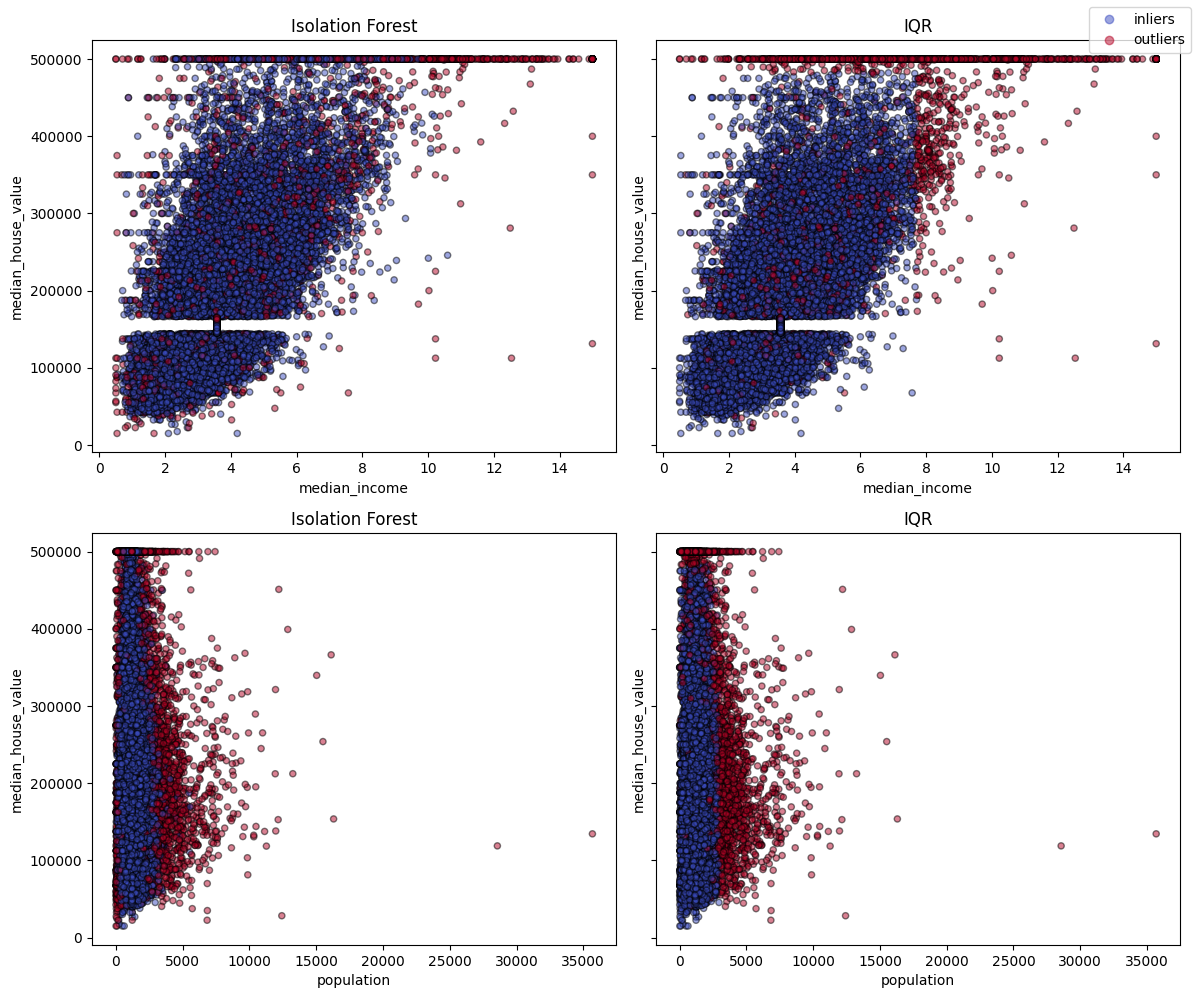

In [1269]:
# number of plots and sizes
fig, ax = plt.subplots(2, 2, figsize=(12, 10), sharey=True)


# median_income and median_house_value
scatter_iso_1 = ax[0, 0].scatter(
    houses_corrupted_copy['median_income'],
    houses_corrupted_copy['median_house_value'],
    c=iso_outliers, cmap='coolwarm', alpha=0.5, edgecolor='k', s=20
)
ax[0, 0].set_title("Isolation Forest")
ax[0, 0].set_xlabel("median_income")
ax[0, 0].set_ylabel("median_house_value")

scatter_iqr_1 = ax[0, 1].scatter(
    houses_corrupted_copy['median_income'],
    houses_corrupted_copy['median_house_value'],
    c=iqr_outliers, cmap='coolwarm', alpha=0.5, edgecolor='k', s=20
)
ax[0, 1].set_title("IQR")
ax[0, 1].set_xlabel("median_income")
ax[0, 1].set_ylabel("median_house_value")


# population and median_house_value
scatter_iso_2 = ax[1, 0].scatter(
    houses_corrupted_copy['population'],
    houses_corrupted_copy['median_house_value'],
    c=iso_outliers, cmap='coolwarm', alpha=0.5, edgecolor='k', s=20
)
ax[1, 0].set_title("Isolation Forest")
ax[1, 0].set_xlabel("population")
ax[1, 0].set_ylabel("median_house_value")

scatter_iqr_2 = ax[1, 1].scatter(
    houses_corrupted_copy['population'],
    houses_corrupted_copy['median_house_value'],
    c=iqr_outliers, cmap='coolwarm', alpha=0.5, edgecolor='k', s=20
)
ax[1, 1].set_title("IQR")
ax[1, 1].set_xlabel("population")
ax[1, 1].set_ylabel("median_house_value")


# legend
fig.legend(handles=handles, labels=["inliers", "outliers"],
           loc="upper right")


# display
plt.tight_layout()
plt.show()

The plots show outliers with median_house_value on the y-axis and median_income on the x-axis in the top row, and population on the x-axis in the bottom row. The left-hand plots show outliers flagged by Isolation Forest, and the right-hand plots show IQR.

When viewing the plots, there are similarities and differences. 

For similarities, I can clearly see that most inliers are gathered together in the same area, as the data for all columns are within the quartile ranges. When just looking at the inliers, it's hard to tell what's different between Isolation Forest and IQR. 

However, when looking only at the outliers, you can see there are some red points that appear in one method but not the other. IQR shows a lot more outliers for both rows, especially ones that are extreme. In contrast, Isolation Forest marks fewer points as outliers, whilst also being more spread out instead of only sitting at the very high ends. 

Some areas that IQR calls outliers are treated as normal by Isolation Forest because even if one value is high, they still follow the general pattern of the rest of the data. This suggests that IQR mainly reacts to very large single values in income, population, or house price, while Isolation Forest looks at how all the features relate to each other. 

Overall, Isolation Forest flags a smaller set of outliers that are unusual overall in the whole dataset, not just extreme based off individual features like IQR. Therefore, I have decided to store that the rows which need to be deleted are those that have been flagged as outliers from both Isolation Forest and IQR. This is so that I have outliers that are shown to be over-extreme, but still have a selective and more analysed approach.

In [1270]:
both_outliers = iqr_outliers & iso_outliers
both_count = both_outliers.sum()
both_percentage = ((both_count / len(houses_corrupted)) * 100).round(2)
print(f'Both Outliers: {both_count} ({both_percentage}%)')

Both Outliers: 2009 (9.73%)


This is the overall percentage of rows from the whole dataset that will be removed, based off the outliers that have been flagged from both detection methods. This will be conducted on the original dataset (houses_corrupted) that contains the null values.

In [1271]:
print(f'Original Shape: {houses_corrupted.shape}')

rows_to_remove = houses_corrupted[both_outliers]
houses_corrupted.drop(index=rows_to_remove.index, inplace=True)

print(f'New Shape: {houses_corrupted.shape}')

Original Shape: (20640, 9)
New Shape: (18631, 9)


The rows with the flagged outliers have now been deleted. You can see the shape of the dataset before and after the process. When calculated, 9.73% (2.d.p) of rows have been removed which is correct.

In [1272]:
houses_corrupted.iloc[90:110]

,median_house_value,median_income,housing_median_age,total_rooms,total_bedrooms,population,households,latitude,longitude
93,187500.0,2.6354,27.0,1055.0,347.0,718.0,302.0,37.79,-122.27
94,179200.0,1.8477,39.0,1715.0,623.0,1327.0,467.0,37.80,-122.27
97,125000.0,2.0062,29.0,335.0,107.0,202.0,91.0,37.81,-122.26
99,193100.0,2.6104,37.0,3633.0,1085.0,1838.0,980.0,37.82,-122.26
102,237500.0,3.1250,39.0,854.0,242.0,389.0,228.0,37.81,-122.25
103,350000.0,2.5795,NaN,2155.0,701.0,895.0,613.0,37.81,-122.25
105,313400.0,4.9306,52.0,1509.0,225.0,674.0,244.0,37.82,-122.24
106,268500.0,3.2727,52.0,2026.0,482.0,709.0,456.0,37.81,-122.24
107,259400.0,3.1691,52.0,1758.0,460.0,686.0,422.0,37.81,-122.25
108,275700.0,3.9000,52.0,3481.0,751.0,1444.0,718.0,37.82,-122.24


Above shows a section of the DataFrame between index 93 and 119. After the deletion of rows, you can see the index row, which is the primary key, has gaps. For example, rows 95,96, 98, 100, 101, 104 and 116 are missing. Therefore, the index needs to reset.

In [1273]:
houses_corrupted = houses_corrupted.reset_index(drop=True)
houses_corrupted.iloc[90:110]

,median_house_value,median_income,housing_median_age,total_rooms,total_bedrooms,population,households,latitude,longitude
90,187500.0,2.6354,27.0,1055.0,347.0,718.0,302.0,37.79,-122.27
91,179200.0,1.8477,39.0,1715.0,623.0,1327.0,467.0,37.80,-122.27
92,125000.0,2.0062,29.0,335.0,107.0,202.0,91.0,37.81,-122.26
93,193100.0,2.6104,37.0,3633.0,1085.0,1838.0,980.0,37.82,-122.26
94,237500.0,3.1250,39.0,854.0,242.0,389.0,228.0,37.81,-122.25
95,350000.0,2.5795,NaN,2155.0,701.0,895.0,613.0,37.81,-122.25
96,313400.0,4.9306,52.0,1509.0,225.0,674.0,244.0,37.82,-122.24
97,268500.0,3.2727,52.0,2026.0,482.0,709.0,456.0,37.81,-122.24
98,259400.0,3.1691,52.0,1758.0,460.0,686.0,422.0,37.81,-122.25
99,275700.0,3.9000,52.0,3481.0,751.0,1444.0,718.0,37.82,-122.24


The index now increments by one.

## 2.4 Benefits and Detriments

These are my overall thoughts on both methods by outlining the benefits and detriments.

#### Statistical method (IQR) 
**Benefits:** 
-  Easy to Explain and Justify: The IQR method uses a simple, fixed rule (Q1 + 1.5 * IQR) and (Q1 + 1.5 * IQR). This provides a clear, traceable boundary for every single outlier, making it easy to explain and justify why specific pieces of data were flagged.
-  Handles missing data: The panda function quantile() used in the method automatically ignores null values. This was perfect to be used on the houses_corrupted dataset. However, as I was required to make comparisons with the Isolation Forest, this benefit was not useful for this section.

**Drawbacks**
-  IQR only checks one feature at a time: Unable to find complex outliers like Isolation Forest since the algorithmic method uses multiple features together, and IQR uses only one. This affects the data that seem fine on their own from just one feature's perspective, but it is clearly an outlier when all are combined.

#### Algorithmic Method (Isolation Forest)

**Benefits:**
-  Finds Complex Outliers: The algorithm looks at all features at once, finding outliers that were missed by checking each column separately. This is shown in section 2.3 where it shows Isolation Forest finding unique outliers that the IQR method didn't.
-  Very fast: Isolation Forest only relies on splitting data. The number of times it splits determines whether it's and outlier or not. This is beneficial as it is very fast to run and test for this assignment.

**Drawbacks:**
-  Struggles with missing data: Temporary median imputation was necessary to ensure a no-risk process to flagging the outliers. As mentioned before, newer versions of Isolation Forest are able to ignore null values as I have tested on my own before. However, this has not been documented on the official website and it is known to not work for other people when using a dataset with null values.
- Unable to justify every flagged outlier: This is particularly the case for those displayed within the dense, central area of the dataset (shown on Section 2.3). While it is clear that a combination of features caused these points to be flagged as an outlier, the number of unique outliers found would mean deep and long analysis which is time-consuming to conduct. Therefore, the final decision to remove them is based on the results produced.

# 3. Imputation [10]
### Tasks:
- Identify which features should be imputed and which should be removed
  - Provide a written rationale for this decision
- Impute the missing records using KNN imputation
- Impute the missing records using MICE imputation
- Compare both imputed datasets feature distributions against each other and the non-imputed data
- Build a regressor on all three datasets
  - Use regression models to predict house median price
  - Compare regressors of non-imputed data against imputed datas
  - **Note**: If you're struggling to compare against the original dataset focus on comparing the two imputed datasets against each other

In [1274]:
# Use this dataset for comparison against the imputed datasets
h_path = 'https://raw.githubusercontent.com/PaoloMissier/CSC3831-2021-22/main/IMPUTATION/TARGET-DATASETS/ORIGINAL/houses.csv'

## 3.1 Identify features to impute or remove

Since I have already identified that there are null values contained inside this dataset (found in section 1.3), I need to make a decision on how to handle them. There are null values contained only in 3 columns: median_income, housing_median_age, and population. The difference between now and then is that the rows with outliers have been removed in section 2.3, whilst before those rows were still existent. Let's see what the difference is now:

In [1275]:
any_missing_rows = houses_corrupted[houses_corrupted.isnull().any(axis=1)]
print(any_missing_rows[null_columns].head(10))
print(any_missing_rows.shape)

    median_income  housing_median_age  population
0          7.2574                52.0         NaN
1          5.6431                52.0         NaN
8          3.2031                 NaN       910.0
12            NaN                52.0      1212.0
14            NaN                52.0       793.0
15            NaN                52.0         NaN
16            NaN                 NaN       990.0
17            NaN                52.0       690.0
18            NaN                40.0       409.0
19            NaN                 NaN       929.0
(5397, 9)


Previously, there were 5,581 rows that contained at least one null value in one of the 3 columns. Now the number has went down to 5,397. You can see there hasn't been a drastic change but regardless we need to still analyse the dataset with null values.

In [1276]:
houses_corrupted.isnull().sum()

median_house_value       0
median_income         1940
housing_median_age    2040
total_rooms              0
total_bedrooms           0
population            2028
households               0
latitude                 0
longitude                0
dtype: int64

This takes us into a deeper look at the 3 columns to see how much each one has been affected. Previously for each of the three columns, there were 2064 null values. Now median_income only has 1940 null values which is over 120 removed. This column has had the biggest affect where housing_median_age has decreased by 24, and population has decreased by 36. 

After all of these changes for data cleaning, the imputation will likely become much more accurate as there are no flagged outliers that will have a heavy affect on calculations. Now I would like to see if there are any rows that have 3 consecutive null values. This will help me decide how to handle them.

In [1277]:
three_missing_rows = houses_corrupted[houses_corrupted[null_columns].isnull().all(axis=1)]
print(three_missing_rows[null_columns])
print(f'three_missing_rows shape: {three_missing_rows.shape}')
print(f'Dataset Shape: {houses_corrupted.shape}')

       median_income  housing_median_age  population
758              NaN                 NaN         NaN
769              NaN                 NaN         NaN
1174             NaN                 NaN         NaN
3829             NaN                 NaN         NaN
4260             NaN                 NaN         NaN
4362             NaN                 NaN         NaN
5613             NaN                 NaN         NaN
5618             NaN                 NaN         NaN
5749             NaN                 NaN         NaN
5753             NaN                 NaN         NaN
5759             NaN                 NaN         NaN
5766             NaN                 NaN         NaN
6367             NaN                 NaN         NaN
6378             NaN                 NaN         NaN
6447             NaN                 NaN         NaN
6456             NaN                 NaN         NaN
6876             NaN                 NaN         NaN
7071             NaN                 NaN      

Previously when I checked this in Section 1.3, 37 rows had 3 consecutive null values. It is still the case now with 37 rows.

The reason I wanted to check this as I have came with the decision to delete those 37 rows as having three missing values makes it too incomplete to repair and impute. Also since there are only 37 rows, which is a very small percentage of the whole dataset, removing them won't change the overall distribution. Therefore, deleting them keeps the dataset cleaner and more trustworthy for analysis.

In [1278]:
houses_corrupted.drop(index=three_missing_rows.index, inplace=True)


The 37 rows have now been deleted. Proof below:

In [1279]:
three_missing_rows = houses_corrupted[houses_corrupted[null_columns].isnull().all(axis=1)]
print(f'three_missing_rows shape (now): {len(three_missing_rows)}')
print(f'Dataset Shape: {houses_corrupted.shape}')

three_missing_rows shape (now): 0
Dataset Shape: (18594, 9)


As some rows have now been deleted, the index needs to be reset:

In [1280]:
houses_corrupted.reset_index(drop=True, inplace=True)

## 3.2 KNN Imputation

KNN (k-nearest-neighbors) is one method of imputation to fill in the missing values. Basically, for a row with at least one missing value, the algorithm finds the k most similar rows that contain non-missing features. It then replaces the null value with an average or most common value of those neighbors. This is much more effective than mean imputation.

**How KNN Imputation Works:**
- Each row is treated as a coordinate
- The distance is calculated between the row with the missing values and other rows
- Identify the neighbors to the selected row that contain similar patterns
- The nearest neighbors are used to fill the missing value. The closer the neighbor, the more influence it has on the imputed value

In [1208]:
from sklearn.impute import KNNImputer

knn_df = houses_corrupted.copy()

selected_columns = ['median_income', 'housing_median_age', 'population']

imputer = KNNImputer(n_neighbors=5)

knn_df[selected_columns] = imputer.fit_transform(knn_df[selected_columns])

Above shows a how I used KNN imputation. As I will be comparing this method with other imputations, I created a copy of the houses_corrupted dataset called knn_df. Then I imputed the 3 columns containing null values: median_income, housing_median_age, and population. I allowed for up to 5 neighbors for each row with missing data to carry out imputation.

Below shows proof that there are no missing values now:

In [1284]:
knn_df.isnull().sum()

median_house_value    0
median_income         0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
latitude              0
longitude             0
dtype: int64

In [1286]:
knn_df.head(20)

,median_house_value,median_income,housing_median_age,total_rooms,total_bedrooms,population,households,latitude,longitude
0,352100.0,7.25740,52.0,1467.0,190.0,1045.6,177.0,37.85,-122.24
1,341300.0,5.64310,52.0,1274.0,235.0,886.2,219.0,37.85,-122.25
2,342200.0,3.84620,52.0,1627.0,280.0,565.0,259.0,37.85,-122.25
3,269700.0,4.03680,52.0,919.0,213.0,413.0,193.0,37.85,-122.25
4,299200.0,3.65910,52.0,2535.0,489.0,1094.0,514.0,37.84,-122.25
5,241400.0,3.12000,52.0,3104.0,687.0,1157.0,647.0,37.84,-122.25
6,226700.0,2.08040,42.0,2555.0,665.0,1206.0,595.0,37.84,-122.26
7,261100.0,3.69120,52.0,3549.0,707.0,1551.0,714.0,37.84,-122.25
8,281500.0,3.20310,30.4,2202.0,434.0,910.0,402.0,37.85,-122.26
9,241800.0,3.27050,52.0,3503.0,752.0,1504.0,734.0,37.85,-122.26


You can see the first 20 rows doesn't contain a single missing value, compared to what the DataFrame showed in section 1.1

## 3.3 MICE Imputation

MICE Imputation stands for Multiple Imputation by Chained Equations. It uses multiple iterations of machine learning model training to predict the missing values using known values from other features in the dataset.

**How MICE Imputation Works:**
- A simple imputation (mean for example), is performed for every missing value in the dataset

In [1210]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

mice_df = houses_corrupted.copy()

imputer = IterativeImputer(max_iter=10, random_state=0)

mice_df[selected_columns] = imputer.fit_transform(houses_corrupted[selected_columns])

In [ ]:
mice_df.isnull().sum()

In [1211]:
mice_df.head(20)

,median_house_value,median_income,housing_median_age,total_rooms,total_bedrooms,population,households,latitude,longitude
0,352100.0,7.257400,52.000000,1467.0,190.0,882.121068,177.0,37.85,-122.24
1,341300.0,5.643100,52.000000,1274.0,235.0,927.113245,219.0,37.85,-122.25
2,342200.0,3.846200,52.000000,1627.0,280.0,565.000000,259.0,37.85,-122.25
3,269700.0,4.036800,52.000000,919.0,213.0,413.000000,193.0,37.85,-122.25
4,299200.0,3.659100,52.000000,2535.0,489.0,1094.000000,514.0,37.84,-122.25
5,241400.0,3.120000,52.000000,3104.0,687.0,1157.000000,647.0,37.84,-122.25
6,226700.0,2.080400,42.000000,2555.0,665.0,1206.000000,595.0,37.84,-122.26
7,261100.0,3.691200,52.000000,3549.0,707.0,1551.000000,714.0,37.84,-122.25
8,281500.0,3.203100,31.470513,2202.0,434.0,910.000000,402.0,37.85,-122.26
9,241800.0,3.270500,52.000000,3503.0,752.0,1504.000000,734.0,37.85,-122.26


## 3.4 Compare feature distributions

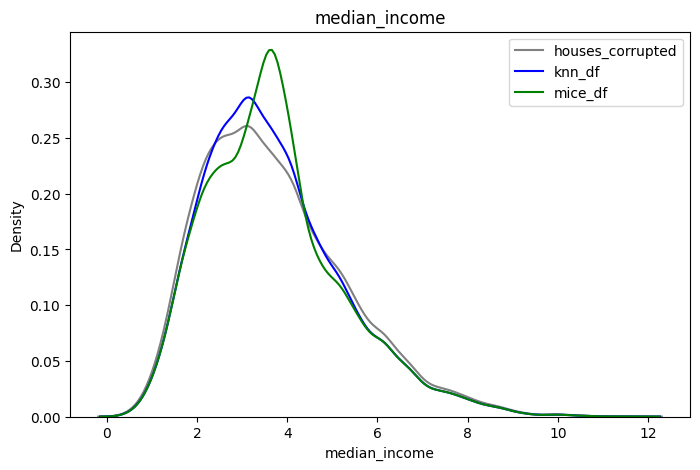

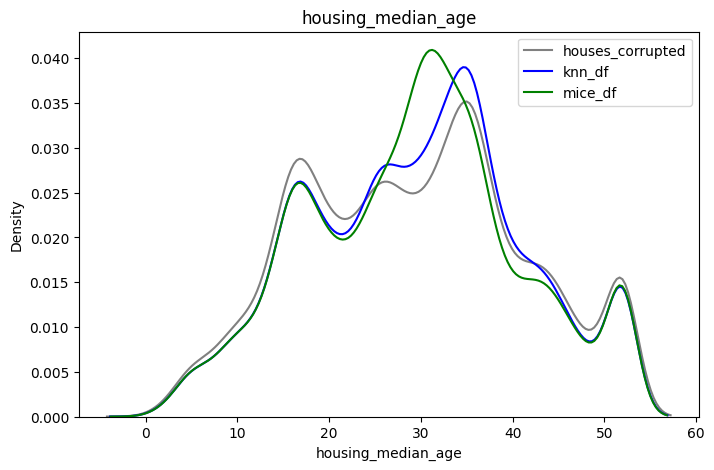

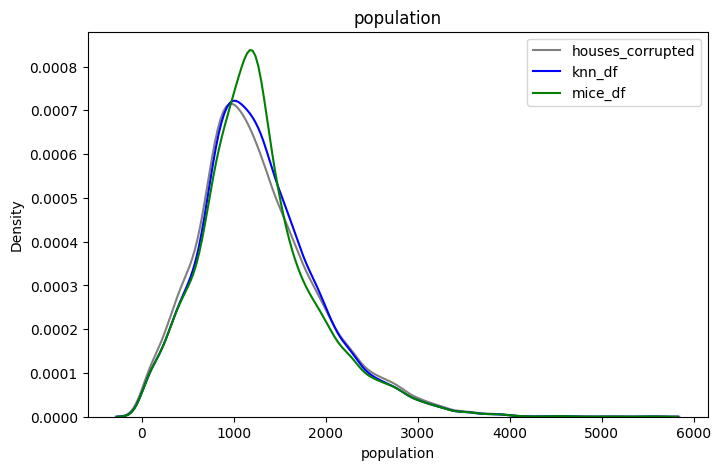

In [1214]:
for col in selected_columns:
    plt.figure(figsize=(8,5))
    sns.kdeplot(houses_corrupted[col], label='houses_corrupted', color='gray')
    sns.kdeplot(knn_df[col], label='knn_df', color='blue')
    sns.kdeplot(mice_df[col], label='mice_df', color='green')
    plt.title(col)
    plt.legend()
    plt.show()

## 3.5 Regressor comparison on three datasets

In [1215]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

datasets = {
    "houses_corrupted": houses_corrupted.dropna(),
    "knn_df": knn_df,
    "mice_df": mice_df
}

for name, data in datasets.items():
    X = data.drop('median_house_value', axis=1)
    y = data['median_house_value']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    model = LinearRegression()
    model.fit(X_train, y_train)

    score = model.score(X_test, y_test)

    print(f"{name}: R² = {score:.4f}")

houses_corrupted: R² = 0.6529
knn_df: R² = 0.5894
mice_df: R² = 0.6022


### 4. Conclusions & Throughts [3]
- Discuss methods used for anomaly detection, pros/cons of each method
- Discuss challenges/difficulties in anomaly detection implementation
- Discuss methods used for imputation, pros/cons of each method
- Discuss challenges/difficulties in imputation implementation